# Lab 2 — Abre el cubo
**Módulo 5 · Clase 2 — Fundamentos de teledetección**

Vas a abrir una **escena Sentinel-2 L2A real** de tu parcela y entenderla como lo que es: un **tensor georreferenciado** (bandas × alto × ancho) con metadatos. Es el segundo commit de tu proyecto.

### Qué vas a hacer
1. **Cargar** una escena multibanda de la parcela desde el **bucket público de AWS** (`sentinel-cogs`, vía earth-search) — **sin login ni credenciales**.
2. Abrirla como **tensor**: shape, dtype, CRS, transform, resolución por banda.
3. Visualizar **color natural** vs **falso color infrarrojo** (la vegetación se vuelve roja).
4. Aplicar la **máscara de nubes SCL** (obligatoria antes de cualquier índice).
5. Recortar a la parcela y **guardar como COG**.

### Rutas
- **Ruta A (guiada):** ejecuta y observa; responde las preguntas finales.
- **Ruta B (ingeniería):** cambia bandas/fechas, usa tu GeoJSON real, exporta el COG y documenta la tabla de bandas.

> **Acceso a datos — solo AWS.** Leemos Sentinel-2 L2A directamente del bucket abierto `sentinel-cogs` (Element84 / earth-search). No necesitas cuenta, credenciales ni créditos: es la vía recomendada para los 11 alumnos. *(Las versiones anteriores con Copernicus openEO y Earth Engine se retiraron de este notebook.)*
>
> Conexión con la teoría: la **firma espectral** dice que la vegetación sana refleja fuerte en el NIR. Por eso el falso color NIR la pinta de rojo brillante.

In [1]:
# --- Instalación (si te faltan paquetes) ---
!pip install -q pystac-client odc-stac rioxarray xarray rasterio numpy matplotlib geopandas

In [2]:
import os
# Acceso anónimo al bucket público de AWS (sentinel-cogs). NO requiere credenciales.
os.environ["AWS_NO_SIGN_REQUEST"] = "YES"
os.environ["AWS_REGION"] = "us-west-2"

import numpy as np, matplotlib.pyplot as plt
import rioxarray  # registra el accesor .rio en xarray (necesario para da.rio.*)
print("Listo — lectura AWS anónima configurada")

Listo — lectura AWS anónima configurada


In [3]:
import geopandas as gpd

# === Parámetros Ruta B: lote real en Argentina ===
aoi = gpd.read_file("data/parcela.geojson").to_crs("EPSG:4326")
BBOX = [float(x) for x in aoi.total_bounds]   # [oeste, sur, este, norte]

FECHA_INICIO = "2024-12-03"
FECHA_FIN    = "2025-04-25"
MAX_NUBES    = 30

BANDAS = ["blue", "green", "red", "nir", "swir16", "scl"]

# Bandas en nomenclatura earth-search (AWS). Entre paréntesis, su nombre Sentinel-2 clásico.
BANDAS = ["blue", "green", "red", "nir", "swir16", "scl"]   # B02, B03, B04, B08, B11, SCL
print("AOI:", BBOX, "| ventana:", FECHA_INICIO, "->", FECHA_FIN)

AOI: [-60.723428, -33.68732, -60.710277, -33.676992] | ventana: 2024-12-03 -> 2025-04-25


## 1. Cargar una escena (ACCESO REAL — earth-search / AWS, sin login)

Buscamos en el catálogo STAC de Element84 la escena **menos nubosa** de la ventana y la cargamos recortada a la parcela con `odc-stac`. La lectura es **anónima** sobre el bucket público `sentinel-cogs`: no hay device-login ni créditos. `odc-stac` remuestrea todas las bandas a una rejilla común de **10 m**.

In [4]:
from pystac_client import Client
from odc.stac import load as odc_load

EARTH_SEARCH = "https://earth-search.aws.element84.com/v1"

def cargar_escena_aws():
    cat = Client.open(EARTH_SEARCH)
    items = list(cat.search(
        collections=["sentinel-2-l2a"],
        bbox=BBOX,
        datetime=f"{FECHA_INICIO}/{FECHA_FIN}",
        query={"eo:cloud_cover": {"lt": MAX_NUBES}},
    ).items())
    if not items:
        raise RuntimeError(f"No hay escenas con nube < {MAX_NUBES}%. Sube MAX_NUBES o amplía las fechas.")
    item = sorted(items, key=lambda it: it.properties["eo:cloud_cover"])[0]  # la menos nubosa
    print("Escena:", item.id, "| fecha:", item.datetime.date(),
          "| nube:", item.properties["eo:cloud_cover"], "%")
    ds = odc_load([item], bands=BANDAS, bbox=BBOX, resolution=10)  # reproyecta + recorta + remuestrea a 10 m
    # Apilamos las bandas en un único tensor (band, y, x):
    da = ds.isel(time=0).to_array(dim="band")
    return da

da = cargar_escena_aws()
print("Cargado tensor con bandas", [str(b) for b in da["band"].values])

Escena: S2A_20HQH_20250115_0_L2A | fecha: 2025-01-15 | nube: 0.003825 %
Cargado tensor con bandas ['blue', 'green', 'red', 'nir', 'swir16', 'scl']


## 2. La escena como tensor

Miramos su **estructura de datos**: forma `(bandas, alto, ancho)`, tipo, sistema de coordenadas (CRS) y la **transform afín** que relaciona píxel ↔ coordenada. Esto es "el dato como tensor".

In [5]:
print("Forma (band, y, x):", da.shape)
print("Bandas:", [str(b) for b in da["band"].values])
print("Tipo de dato:", da.dtype)
print("CRS:", da.rio.crs)
print("Resolución (m):", da.rio.resolution())
print("Transform afín:\n", da.rio.transform())
print("BBox proyectado:", da.rio.bounds())

Forma (band, y, x): (6, 119, 125)
Bandas: ['blue', 'green', 'red', 'nir', 'swir16', 'scl']
Tipo de dato: uint16
CRS: EPSG:32720
Resolución (m): (10.0, -10.0)
Transform afín:
 | 10.00, 0.00, 711020.00|
| 0.00,-10.00, 6271340.00|
| 0.00, 0.00, 1.00|
BBox proyectado: (711020.0, 6270150.0, 712270.0, 6271340.0)


In [6]:
# Tabla de bandas (nombre earth-search -> Sentinel-2 clásico y uso agronómico)
tabla = {
 "blue":   ("B02", "Blue",  490, "10 m", "color natural; máscara de agua"),
 "green":  ("B03", "Green", 560, "10 m", "vigor general; GNDVI"),
 "red":    ("B04", "Red",   665, "10 m", "absorción clorofila; NDVI"),
 "nir":    ("B08", "NIR",   842, "10 m", "vigor/biomasa; NDVI"),
 "swir16": ("B11", "SWIR1",1610, "20 m", "agua foliar; NDWI; estrés hídrico"),
 "scl":    ("SCL", "Scene Classification", None, "20 m", "máscara de nubes/sombra"),
}
print(f"{'earth-search':12} {'S2':4} {'Nombre':22} {'λ(nm)':6} {'Res':5} Uso")
for b in BANDAS:
    s2, n, lam, res, uso = tabla[b]
    print(f"{b:12} {s2:4} {n:22} {str(lam):6} {res:5} {uso}")

earth-search S2   Nombre                 λ(nm)  Res   Uso
blue         B02  Blue                   490    10 m  color natural; máscara de agua
green        B03  Green                  560    10 m  vigor general; GNDVI
red          B04  Red                    665    10 m  absorción clorofila; NDVI
nir          B08  NIR                    842    10 m  vigor/biomasa; NDVI
swir16       B11  SWIR1                  1610   20 m  agua foliar; NDWI; estrés hídrico
scl          SCL  Scene Classification   None   20 m  máscara de nubes/sombra


## 3. Color natural vs falso color infrarrojo

- **Color natural** = (R=red, G=green, B=blue): como lo vería el ojo.
- **Falso color NIR** = (R=nir, G=red, B=green): la **vegetación sana se vuelve roja brillante** porque refleja mucho en el NIR. Es la firma espectral hecha imagen.

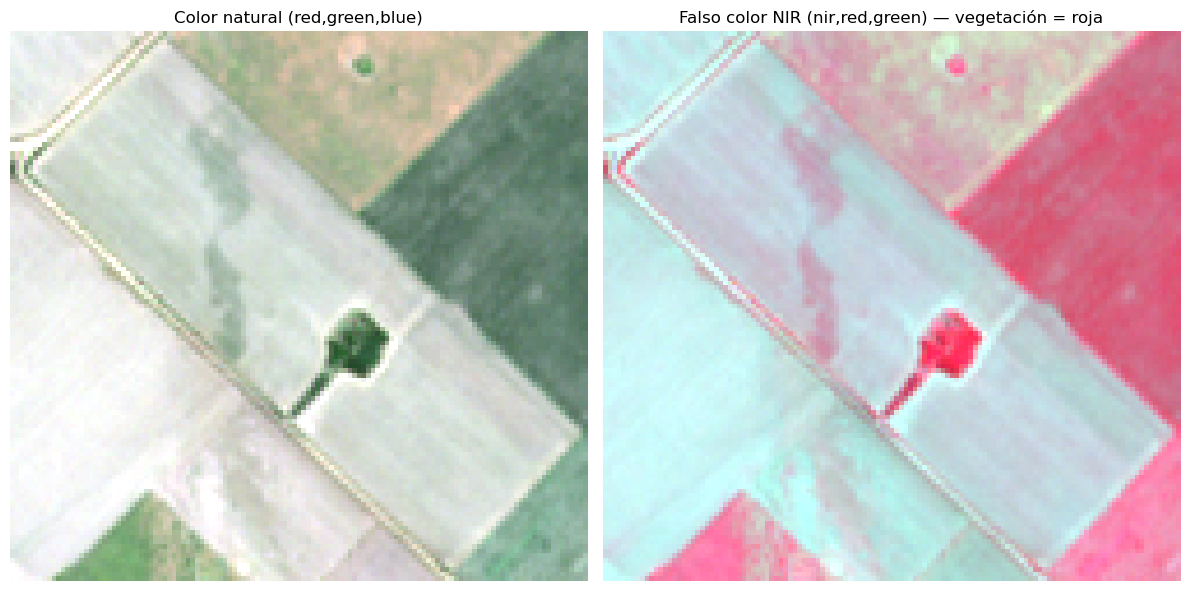

In [7]:
def stretch(rgb, p=98):
    # Estira el contraste para visualizar reflectancias (enteros 0..~10000).
    out = np.zeros_like(rgb, dtype="float32")
    for i in range(rgb.shape[-1]):
        ch = rgb[..., i].astype("float32")
        hi = np.nanpercentile(ch, p) or 1.0
        out[..., i] = np.clip(ch / hi, 0, 1)
    return out

def banda(nombre):
    return da.sel(band=nombre).values

natural = np.dstack([banda("red"), banda("green"), banda("blue")])
falso   = np.dstack([banda("nir"), banda("red"),   banda("green")])

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(stretch(natural)); ax[0].set_title("Color natural (red,green,blue)"); ax[0].axis("off")
ax[1].imshow(stretch(falso));   ax[1].set_title("Falso color NIR (nir,red,green) — vegetación = roja"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## 4. Máscara de nubes (SCL) — obligatoria

La banda **SCL** (Scene Classification Layer) clasifica cada píxel. Para análisis agrícola nos quedamos con **vegetación (4)**, **suelo (5)** y **sin clasificar (7)**, y descartamos nubes/sombras. **Nunca** se calcula un índice sin enmascarar antes.

Píxeles válidos (no nube/sombra): 100.0%


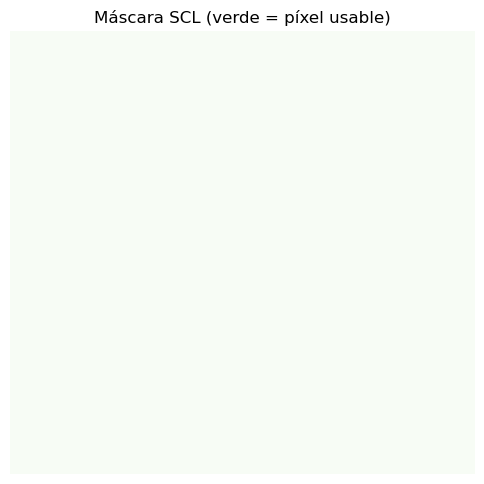

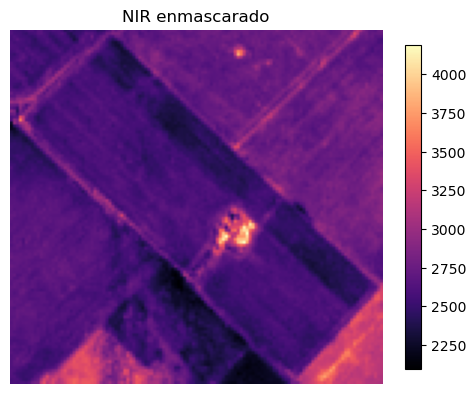

In [8]:
scl = banda("scl")
validos = np.isin(scl, [4, 5, 7])          # veg, suelo, unclassified
pct = 100 * validos.mean()
print(f"Píxeles válidos (no nube/sombra): {pct:.1f}%")

plt.figure(figsize=(6,6))
plt.imshow(validos, cmap="Greens"); plt.title("Máscara SCL (verde = píxel usable)"); plt.axis("off"); plt.show()

# Aplica la máscara a una banda de ejemplo (NIR) para ver el efecto
nir = banda("nir").astype("float32"); nir[~validos] = np.nan
plt.figure(figsize=(6,6)); plt.imshow(nir, cmap="magma"); plt.title("NIR enmascarado"); plt.axis("off"); plt.colorbar(shrink=.7); plt.show()

## 5. Recortar a la parcela y guardar como COG (Ruta B)

Ya cargamos recortado al BBOX. Si tienes la geometría real (`data/parcela.geojson`), recorta el tensor a la parcela y guárdalo como **Cloud-Optimized GeoTIFF**, el formato que usaremos en las siguientes clases.

In [9]:
# Ruta B: recorte por geometría real
# import geopandas as gpd
# aoi = gpd.read_file("data/parcela.geojson").to_crs(da.rio.crs)
# da = da.rio.clip(aoi.geometry, aoi.crs)

# Guardar como COG (requiere driver COG de rasterio/GDAL >= 3.1)
try:
    da.rio.to_raster("escena_parcela_cog.tif", driver="COG")
    print("Guardado: escena_parcela_cog.tif (COG)")
except Exception as ex:
    da.rio.to_raster("escena_parcela.tif")  # fallback GeoTIFF normal
    print("COG no disponible; guardado GeoTIFF normal. Detalle:", ex)

Guardado: escena_parcela_cog.tif (COG)


## 6. Preguntas para entregar

1. ¿Qué forma `(bandas, alto, ancho)` tiene tu escena y qué CRS usa? ¿Qué significa la *transform afín*?
2. Compara color natural y falso color NIR: ¿dónde se ve más "viva" la vegetación y por qué?
3. ¿Qué porcentaje de píxeles válidos quedó tras la máscara SCL? ¿Por qué es obligatorio enmascarar antes de calcular índices?
4. (Ruta B) ¿Qué ventaja tiene guardar en COG frente a un GeoTIFF normal?

**Entrega:** notebook ejecutado + tabla de bandas completada + (Ruta B) el COG recortado. **Segundo commit.** Fecha límite: antes de la Clase 3 (18/06).

¿Qué forma (bandas, alto, ancho) tiene tu escena y qué CRS usa? ¿Qué significa la transform afín?
La escena procesada tiene una forma de 6 bandas espectrales, 119 filas y 125 columnas. El sistema de referencia de coordenadas utlizado es EPSG: 32720 (UTM zona 20 Sur, WG84),adecuado para la ubicación del lote en Argentina. La transform afín establece la relación enttre la posición de cada pixel y sus coordenadas reales en el terreno, permitiendo georreferenciar correctamente la imagen y conocer el tamaño de pixel (10 x 10 m). La escena se procesó con una resolución espacial de 10 metros.

Compara olor natural y falso color NIR ¿Dónde se ve más viva la vegetación y por qué?
La vegetación se observa con mayor claridad en la composición de falso color infrarrojo (NIR), ya que las plantas sanas reflejan intesamente la radiación del infrarrojo cercano. En la magen RGB la vegetación aparece con tonalidades verdes naturales, mientras que en el NIR resalta con colores mucho más intensos, facilitando la identificación de diferencias de vigor en el lote.

¿Que porcentaje de pixeles válidos quedó trás la máscara SCL?¿?Por qué es obligatorio enmascarar antes de calcular índices?


¿Que ventaja tiene guardar en COG frente a un GeoTIFF normal?
Un Cloud Optimized GeoTIFF, conocido como COG por sus siglas, permite acceder únicamente a la porción de la imagen que se necesita, sin descargar el archivo completo. Eto mejora el rendimiento al trabajar con imággenes satelitales de gran tamaño, reduce el consumo de ancho de banda y facilita el procesamiento remoto en plataformas geoespaciales y aplicaciones de agricultura de precisión.